# Test code for genmag_exact profile

20260913-15
Kyoko Kusano

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from genmag_exact.genmag_profile import GenmagProfile

mf = GenmagProfile.from_distance_matrix([[0, 1], [1, 0]])
print(mf.num, mf.den, mf.x_scale, mf.limit)
# expected: (2,) (1, 1) 1 2

assert mf.limit == 2
assert sum(mf.num) / sum(mf.den) == 1        # the m(1) = 1 invariant
print("ok")

(Fraction(2, 1),) (Fraction(1, 1), Fraction(1, 1)) 1 2
ok


In [9]:
# ---- step 2 の動作確認 ----
import sympy as sp
import mpmath as mp
from fractions import Fraction

from genmag_exact.genmag_profile import GenmagProfile   # ← ファイル名に合わせる
from genmag_exact import schur_value

ok = True

# 確認1: 2点空間。手計算で m(x) = 2/(1+x) と出したもの。
print("--- 確認1: 2x2 ---")
profile_2 = GenmagProfile.from_distance_matrix([[0, 1], [1, 0]])
expected_2 = {0: "1.0", 0.5: "1.24491866240370913", 1: "1.46211715726000976",
              5: "1.98661429815143029", 10: "1.99990920426259513"}
for t, expected in expected_2.items():
    value, dps_used, digits_lost = profile_2.genmag_at(t)
    got = mp.nstr(value, 18)
    match = got == expected
    ok &= match
    print(f"  t={t:<5} value={got:<22} expected={expected:<22} {'OK' if match else 'NG'}")

# 確認2: 5点空間。別アルゴリズム (schur_value) と一致するか。
print("\n--- 確認2: 5x5 を schur_value と突き合わせ ---")
D5 = [[0,1,0,1,2],[1,0,2,0,1],[0,2,0,1,0],[1,0,1,0,2],[2,1,0,2,0]]
profile_5 = GenmagProfile.from_distance_matrix(D5)
for t in [0.3, 1, 5, 20]:
    value, dps_used, digits_lost = profile_5.genmag_at(t)
    reference = schur_value(D5, t, dps=50).total
    difference = abs(value - reference)
    match = difference < mp.mpf("1e-15")
    ok &= match
    print(f"  t={t:<5} diff={mp.nstr(difference, 3):<12} {'OK' if match else 'NG'}")

# 確認3: 桁落ちの自動修復。(1-x)^12 を分子にした人工的な profile。
print("\n--- 確認3: 桁落ちの自動修復 ---")
symbol = sp.symbols("symbol")
coefficients = [Fraction(int(c))
                for c in reversed(sp.Poly(sp.expand((1 - symbol) ** 12), symbol).all_coeffs())]
disaster = GenmagProfile(
    num=tuple(coefficients), den=(Fraction(1),), x_scale=1,
    limit=None, m_at_infinity=Fraction(0),
    generic_rank=0, rank_at_infinity=0, method="synthetic test",
)
t_for_x_099 = float(-mp.log(mp.mpf("0.99")))     # x = 0.99 になる t
for start_dps in (15, 30, 50):
    value, dps_used, digits_lost = disaster.genmag_at(t_for_x_099, dps=start_dps)
    match = abs(value - mp.mpf("1e-24")) < mp.mpf("1e-30")
    ok &= match
    print(f"  start dps={start_dps:<3} value={mp.nstr(value, 10):<14} "
          f"dps_used={dps_used:<5} digits_lost={digits_lost:.1f}  {'OK' if match else 'NG'}")

print("\n=====", "ALL OK" if ok else "どこか NG", "=====")

--- 確認1: 2x2 ---
  t=0     value=1.0                    expected=1.0                    OK
  t=0.5   value=1.24491866240370913    expected=1.24491866240370913    OK
  t=1     value=1.46211715726000976    expected=1.46211715726000976    OK
  t=5     value=1.98661429815143029    expected=1.98661429815143029    OK
  t=10    value=1.99990920426259513    expected=1.99990920426259513    OK

--- 確認2: 5x5 を schur_value と突き合わせ ---
  t=0.3   diff=8.51e-18     OK
  t=1     diff=0.0          OK
  t=5     diff=0.0          OK
  t=20    diff=5.35e-51     OK

--- 確認3: 桁落ちの自動修復 ---
  start dps=15  value=1.0e-24        dps_used=60    digits_lost=27.6  OK
  start dps=30  value=1.0e-24        dps_used=60    digits_lost=27.6  OK
  start dps=50  value=1.0e-24        dps_used=50    digits_lost=27.6  OK

===== ALL OK =====


In [12]:
# ---- step 3 の動作確認 ----
import numpy as np
from genmag_exact.genmag_profile import GenmagProfile

# 確認1: 2点空間。t=0 で 1、t が大きいと 2 に近づき、その間ずっと単調増加のはず。
print("--- 確認1: 2x2 の曲線の形 ---")
profile_2 = GenmagProfile.from_distance_matrix([[0, 1], [1, 0]])
t_values = np.logspace(-2, 2, 200)
values, dps_used, digits_lost = profile_2.genmag_curve(t_values)

print(f"  点の数        : {len(values)}")
print(f"  左端 t={t_values[0]:.4f} : {values[0]:.10f}")
print(f"  右端 t={t_values[-1]:.1f}  : {values[-1]:.10f}   (limit = {profile_2.limit})")
print(f"  広義単調増加か     : {all(a <= b for a, b in zip(values, values[1:]))}")
print(f"  最大 digits_lost : {max(digits_lost):.2f}")
print(f"  dps を上げた点の数 : {sum(1 for d in dps_used if d > 50)}")

# 確認2: 5点空間。右端が exact limit (7/3) に乗り、m_at_infinity (2) ではないこと。
print("\n--- 確認2: 5x5 の右端はどちらの線に乗るか ---")
D5 = [[0,1,0,1,2],[1,0,2,0,1],[0,2,0,1,0],[1,0,1,0,2],[2,1,0,2,0]]
profile_5 = GenmagProfile.from_distance_matrix(D5)
values_5, _, _ = profile_5.genmag_curve(np.logspace(-2, 2, 200))
print(f"  右端の値        : {values_5[-1]:.12f}")
print(f"  limit           : {float(profile_5.limit):.12f}")
print(f"  m_at_infinity   : {float(profile_5.m_at_infinity):.12f}")
print(f"  limit に一致するか : {abs(values_5[-1] - float(profile_5.limit)) < 1e-12}")

# 確認3: 単体の genmag_at と同じ値が出るか。
print("\n--- 確認3: genmag_at と一致するか ---")
for t in [0.1, 1.0, 10.0]:
    single, _, _ = profile_5.genmag_at(t)
    curve, _, _ = profile_5.genmag_curve([t])
    print(f"  t={t:<5} genmag_at={float(single):.12f}  genmag_curve={curve[0]:.12f}  "
          f"{'OK' if abs(float(single) - curve[0]) < 1e-15 else 'NG'}")

--- 確認1: 2x2 の曲線の形 ---
  点の数        : 200
  左端 t=0.0100 : 1.0049999583
  右端 t=100.0  : 2.0000000000   (limit = 2)
  減少していないか     : True
  最大 digits_lost : 0.00
  dps を上げた点の数 : 0

--- 確認2: 5x5 の右端はどちらの線に乗るか ---
  右端の値        : 2.333333333333
  limit           : 2.333333333333
  m_at_infinity   : 2.000000000000
  limit に一致するか : True

--- 確認3: genmag_at と一致するか ---
  t=0.1   genmag_at=1.079868694890  genmag_curve=1.079868694890  OK
  t=1.0   genmag_at=1.700189677592  genmag_curve=1.700189677592  OK
  t=10.0  genmag_at=2.333242535306  genmag_curve=2.333242535306  OK


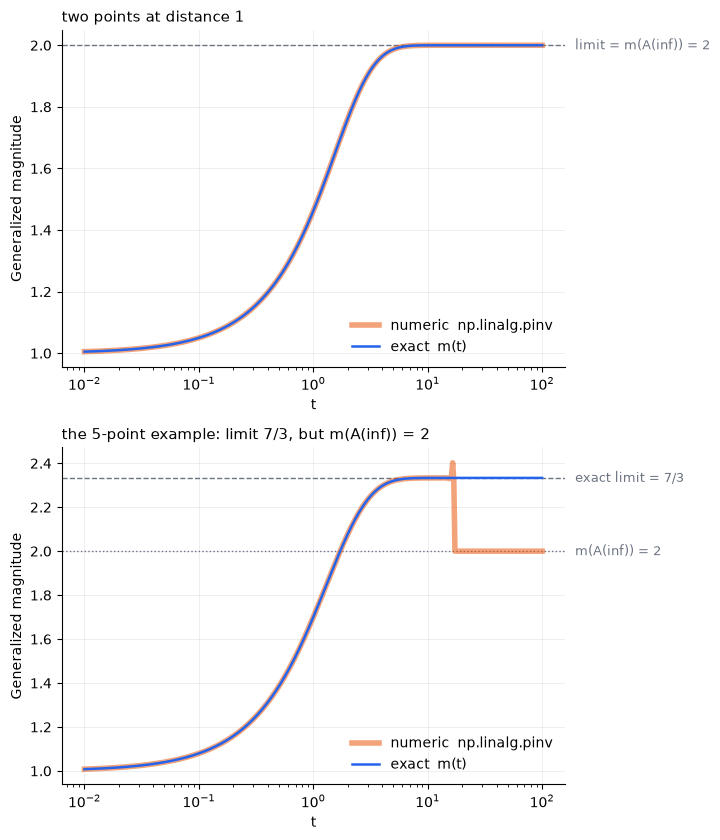

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from genmag_exact.genmag_profile import GenmagProfile

EXACT_COLOR = "#2563eb"    # blue
NUMERIC_COLOR = "#ea580c"  # orange
GUIDE_COLOR = "#6b7280"    # grey for the reference lines


def plot_genmag_profile(D, title, t_values=None, ax=None):
    """Draw the genmag profile of one distance matrix: exact against numeric.

    The exact curve comes from the rational function m(x); the numeric curve
    redoes the pseudo-inverse at every t, the way qstr_diversity does.
    """
    if t_values is None:
        t_values = np.logspace(-2, 2, 400)

    profile = GenmagProfile.from_distance_matrix(D)
    exact_values, _, _ = profile.genmag_curve(t_values)

    D_array = np.asarray(D, dtype=float)
    numeric_values = [float(np.sum(np.linalg.pinv(np.exp(-t * D_array))))
                      for t in t_values]

    if ax is None:
        _, ax = plt.subplots(figsize=(7.5, 4.5))

    limit = float(profile.limit)
    m_at_infinity = float(profile.m_at_infinity)

    # Reference lines. When the two coincide, draw and label only one.
    if abs(limit - m_at_infinity) < 1e-12:
        ax.axhline(limit, color=GUIDE_COLOR, lw=1, ls="--", zorder=1)
        ax.annotate(f"limit = m(A(inf)) = {profile.limit}",
                    xy=(1.02, limit), xycoords=("axes fraction", "data"),
                    va="center", fontsize=9, color=GUIDE_COLOR)
    else:
        ax.axhline(limit, color=GUIDE_COLOR, lw=1, ls="--", zorder=1)
        ax.axhline(m_at_infinity, color=GUIDE_COLOR, lw=1, ls=":", zorder=1)
        ax.annotate(f"exact limit = {profile.limit}",
                    xy=(1.02, limit), xycoords=("axes fraction", "data"),
                    va="center", fontsize=9, color=GUIDE_COLOR)
        ax.annotate(f"m(A(inf)) = {profile.m_at_infinity}",
                    xy=(1.02, m_at_infinity), xycoords=("axes fraction", "data"),
                    va="center", fontsize=9, color=GUIDE_COLOR)

    # Numeric is drawn thick and underneath, so it still shows as a halo
    # wherever the two curves agree.
    ax.plot(t_values, numeric_values, lw=4, alpha=0.55, color=NUMERIC_COLOR,
            label="numeric  np.linalg.pinv", zorder=2)
    ax.plot(t_values, exact_values, lw=1.8, color=EXACT_COLOR,
            label="exact  m(t)", zorder=3)

    ax.set_xscale("log")
    ax.set_xlabel("t")
    ax.set_ylabel("Generalized magnitude")
    ax.set_title(title, fontsize=11, loc="left")
    ax.grid(True, lw=0.5, color="#e5e7eb", zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.legend(frameon=False, loc="lower right")
    return ax


fig, axes = plt.subplots(2, 1, figsize=(7.5, 8.5))
plot_genmag_profile([[0, 1], [1, 0]],
                    "two points at distance 1", ax=axes[0])
plot_genmag_profile([[0,1,0,1,2],[1,0,2,0,1],[0,2,0,1,0],[1,0,1,0,2],[2,1,0,2,0]],
                    "the 5-point example: limit 7/3, but m(A(inf)) = 2", ax=axes[1])
fig.tight_layout()
fig.subplots_adjust(right=0.76)

In [16]:
import numpy as np
from genmag_exact.genmag_profile import GenmagProfile, break_at_poles

# 極を4つ持つことが分かっている行列
rng = np.random.default_rng(0)
U = rng.integers(1, 10, size=(12, 12)); U = np.triu(U, 1); D_poles = (U + U.T).tolist()

profile = GenmagProfile.from_distance_matrix(D_poles)
poles = profile.poles()
print("極の t:", [round(p, 6) for p in poles])
print("期待値 : [0.046493, 0.303887, 0.441124, 0.928159]")

# 極のすぐ左右で符号が反転するか（極の定義そのもの）
for pole in poles:
    left, _, _ = profile.genmag_at(pole * (1 - 1e-9))
    right, _, _ = profile.genmag_at(pole * (1 + 1e-9))
    print(f"  t={pole:.6f}  左={float(left):>14.1f}  右={float(right):>14.1f}  "
          f"符号反転: {float(left) * float(right) < 0}")

# 極のない行列では空リストが返るか
profile_2 = GenmagProfile.from_distance_matrix([[0, 1], [1, 0]])
print("\n2点空間の極:", profile_2.poles(), "(空のはず)")

# break_at_poles が nan を正しい本数だけ挟むか
t_values = list(np.logspace(-2, 2, 800))
values, _, _ = profile.genmag_curve(t_values)
t_broken, v_broken = break_at_poles(t_values, values, poles)
print(f"\n元の点数: {len(values)}  切った後: {len(v_broken)}  "
      f"nan の数: {sum(1 for v in v_broken if v != v)}")

極の t: [0.046493, 0.303887, 0.441124, 0.928159]
期待値 : [0.046493, 0.303887, 0.441124, 0.928159]
  t=0.046493  左=  -304817413.7  右=   304817412.5  符号反転: True
  t=0.303887  左=    -1741378.8  右=     1741385.9  符号反転: True
  t=0.441124  左=    -1677097.2  右=     1677106.3  符号反転: True
  t=0.928159  左=   -57942553.5  右=    57942565.3  符号反転: True

2点空間の極: [] (空のはず)

元の点数: 800  切った後: 804  nan の数: 4
